In [1]:
library(Seurat)
library(data.table)
library(dplyr)
library(ggplot2)
library(parallel)

Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
io = list() 
io$outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/sherwood/'

In [3]:
seurat = readRDS('/rds/project/rds-SDzz0CATGms/users/ltgh2/projects/04_Gifford_invitro_mESC/processed_objects/seurat_objects/seurat_mesendoderm_labels_GSM3452922.Rds')

In [12]:
# haemoglobin genes show up as differential expressed in all cell-types when there is a differential abundance in erythroids
# We hypothesise this is due to bursting of the erythroids, resulting in large amount of ambient haemoglobin RNA.
gene_biomart = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt')
all_genes = gene_biomart$symbol
haem_genes = all_genes[c(grep('Hba', all_genes),
                         grep('Hbb', all_genes))]

# Genes on the y-chr can be differential due to the injected ESC being male, while the host can be either male or female
y_genes = gene_biomart[chr=='chrY', symbol]

# Some genes on the x-chr can be differential for the same reason
# Xist and Tsix are known to often be differentially expressed 
x_genes = c('Xist', 'Tsix')

# Additionally there are some paternally or maternally expressed genes to remove
imprint = gene_biomart[c(grep('maternally', gene_biomart$description),
                       grep('paternally', gene_biomart$description)), symbol]
imprint = c(imprint, 'Grb10', 'Nnat')

# Remove all other genes that are not informative, e.g. mitochondrial/ribosomal/predicted genes etc
non_informative = all_genes[grep("*Rik|^Gm|^mt-|^Rps|^Rpl|^Olfr", all_genes)]

# Genes differential from WT injection experiment
#WT_inj = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/old/tomato_DEGs_edgeR.csv')

# Tomato-td is differentially expressed, because it is only present in the KO cells
excl_genes = intersect(c(haem_genes, y_genes, x_genes, imprint, non_informative, 'tomato-td'), rownames(seurat))


In [20]:
seurat = seurat[!rownames(seurat) %in% excl_genes,]

In [21]:
seurat <- NormalizeData(seurat)
seurat <- FindVariableFeatures(seurat, selection.method = "vst", nfeatures = 2000)

In [22]:
seurat <- ScaleData(seurat)

Centering and scaling data matrix



In [23]:
seurat <- RunPCA(seurat, features = VariableFeatures(object = seurat))

PC_ 1 
Positive:  Fabp5, Ifitm1, Lgals1, Phlda2, Nkd1, Ifitm2, Sox11, Lmo2, Cdx1, Axin2 
	   Sp5, Grsf1, Mdk, Fn1, Hspa8, Fzd10, Hoxb2, Mixl1, Lef1, Crabp1 
	   Ccnd2, Ccnd1, Sox4, T, Hoxb1, Notum, Slc38a4, Tuba1a, Cald1, Cdkn1c 
Negative:  Cubn, Srgn, Dab2, Lama1, Lrp2, Atp1b1, Pth1r, Col4a1, Fam134b, Ctsh 
	   Col4a2, Spink1, S100g, Fabp3, Foxq1, Amn, Aqp8, Sparc, Sox17, Lgmn 
	   Sox7, Gata4, Nostrin, Kdelr3, Lamc1, Hs3st1, Gata6, Glipr1, Cryab, Lrpap1 
PC_ 2 
Positive:  Klf2, Mt2, Mylpf, Dppa5a, Chchd10, Sox2, Utf1, Mt1, Tdh, Zfp42 
	   Morc1, Mkrn1, Nanog, Lncenc1, Gdf3, Platr10, Gsta4, Prrc1, L1td1, Dppa3 
	   Hsp90aa1, Platr3, Tfcp2l1, Ldhb, Rbmxl2, Pou5f1, Lima1, Dpys, Spp1, Tcea3 
Negative:  Serpinh1, Tpm4, Ccnd2, Nkd1, Igf2, Tmsb10, Cald1, Krt8, Phlda2, Sox11 
	   Prtg, Tuba1a, Col1a1, Lgals1, Hmga2, Tpm1, Nrp1, Gpc3, Scd2, Limd2 
	   Runx1, Wnt5a, Ptms, Cited1, Bambi, Fn1, Tmsb4x, Cmtm7, Sparc, Greb1 
PC_ 3 
Positive:  Krt8, Krt18, Hand1, Vim, Pmp22, Mest, Amot, Ifitm3, Marc

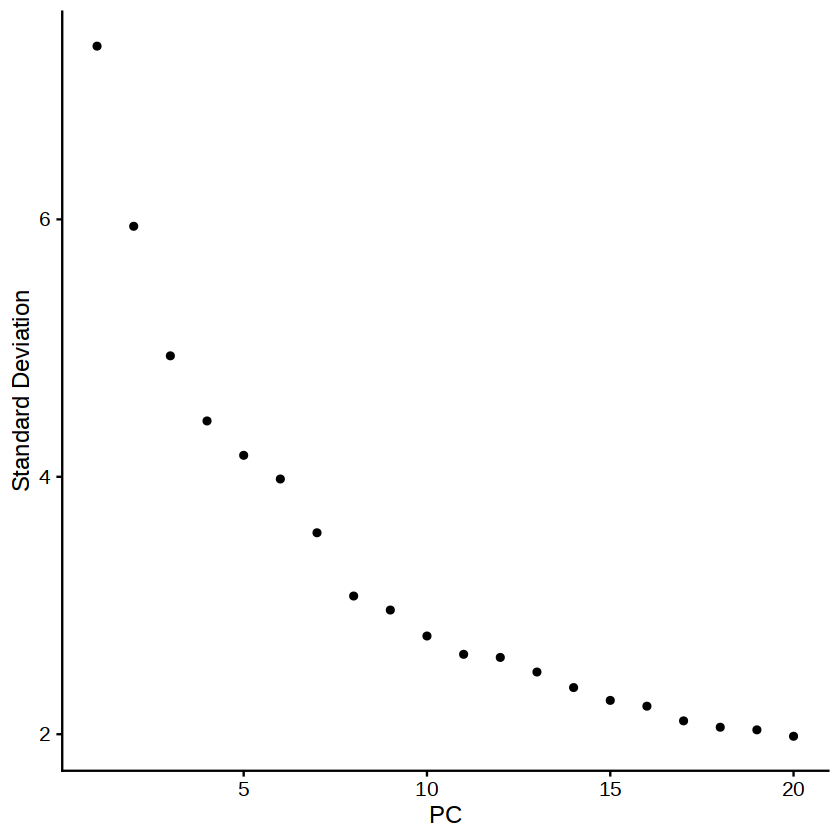

In [24]:
ElbowPlot(seurat)

In [25]:
seurat <- RunUMAP(seurat, dims = 1:15, verbose=F)

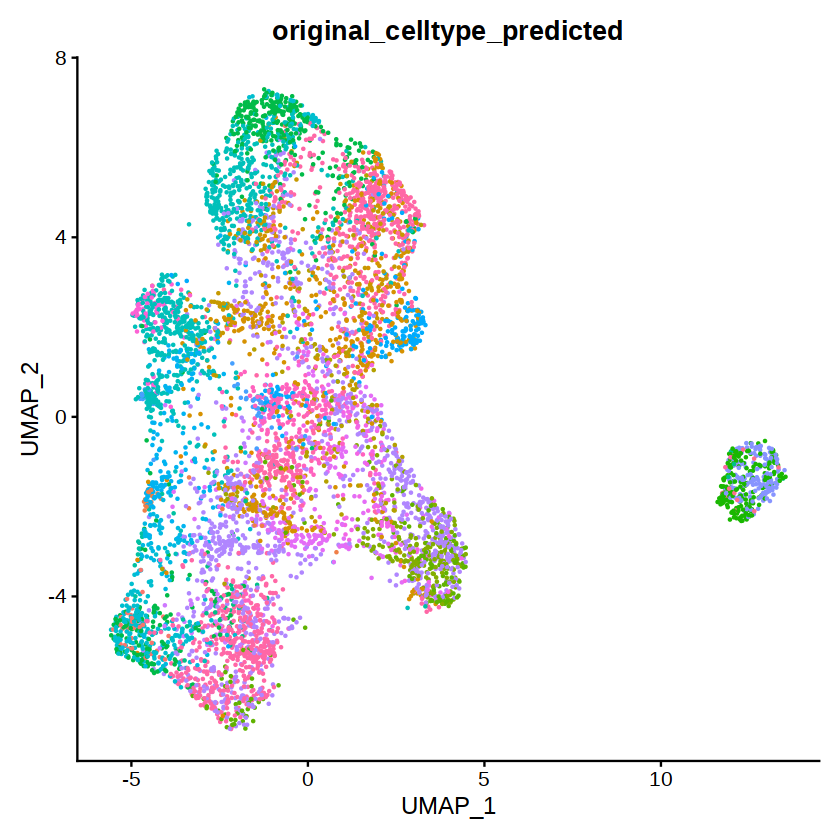

In [26]:
DimPlot(seurat, reduction = "umap", group.by='original_celltype_predicted') + theme(legend.position='none')

In [27]:
meta = as.data.table(seurat@meta.data, keep.rownames=T) %>% setnames('rn', 'cell')

In [28]:
## Get imputed data matrix
#get distance matrix
PCA = seurat@reductions$pca@cell.embeddings
NN = BiocNeighbors::findKNN(PCA, 10)

impute = function(x){
    tmp = as.matrix(rowMeans(logcounts[,NN[[1]][x,]]))
    colnames(tmp) = colnames(logcounts)[x]
    tmp = as.data.frame(tmp)
    return(tmp)
}

In [29]:
logcounts = seurat@assays$RNA@data[VariableFeatures(object = seurat),]

In [30]:
dim(logcounts)

[1] 2000 6800

In [31]:
a = Sys.time()
logcounts_imputed = mclapply(1:dim(logcounts)[2], impute, mc.cores=1)
b = Sys.time()
b-a

Time difference of 15.43424 secs

In [32]:
logcounts_imputed_matrix = bind_cols(logcounts_imputed)
rownames(logcounts_imputed_matrix) = rownames(logcounts)

In [33]:
# Prepare metadata
colnames(meta)

[1] "cell"                              "orig.ident"                       
 [3] "nCount_RNA"                        "nFeature_RNA"                     
 [5] "is_valid"                          "top_3_frac"                       
 [7] "assignment"                        "total_count"                      
 [9] "RA"                                "TgfB"                             
[11] "Notch"                             "Shh"                              
[13] "Wnt"                               "Bmp"                              
[15] "Fgf"                               "pass"                             
[17] "cell"                              "extended_celltype_predicted"      
[19] "extended_celltype_predicted.score" "original_celltype_predicted"      
[21] "original_celltype_predicted.score" "stage_predicted"                  
[23] "stage_predicted.score"

In [34]:
treatment = meta[!is.na(RA),c('cell', 'RA', 'TgfB', 'Notch','Shh', 'Wnt', 'Bmp', 'Fgf')] 

In [35]:
logcounts_imputed_matrix = logcounts_imputed_matrix[,treatment$cell]

In [36]:
head(treatment)

cell,RA,TgfB,Notch,Shh,Wnt,Bmp,Fgf
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TTCTACAAGGGTCGAT-1,1,0,1,1,1,0,0
GCATGATAGCGCTTAT-1,0,0,1,1,1,1,0
AGCGTCGTCTTGCATT-1,1,1,0,0,1,1,0
GTGCGGTGTAGCTGCC-1,0,0,1,1,1,1,0
ACGAGCCGTCCAACTA-1,1,1,0,1,0,0,1
CGATGTAGTAAGAGAG-1,1,0,1,0,0,1,0


In [37]:
unique = unique(treatment[,-'cell']) %>% .[,combination:=.I]

In [38]:
treatment = merge(treatment, unique, by=c('RA', 'TgfB', 'Notch','Shh', 'Wnt', 'Bmp', 'Fgf'))

In [39]:
table(treatment$combination)


  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
 48  40  16  27  31  31  43  19  33  51  44  25  19  56  29 106  33  96  20  13 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
 18  19  12  67  25  22  39  31  22  28  44  44  16  51  11  25  14  31  48  30 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
 35  19  38  21  17  31  34   9  14  29  42  21  31  29  48  31  36  22  27  29 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
 19  16  12  35  21  13  60  75  31  17  10  28  39  30  52  46  28  23  15  18 
 81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 
 19  33  24  46  17  21  21  20   7  32  35  41  12  15  15  26  22  29  22  33 
101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 
 39  25  13  15  25  25  30  16  35  17  45  17   5  15   8  23  25  20  13  16 
121 122 123 124 125 126 127

In [40]:
train_val = treatment[combination %in% c(15:105)][, -'combination']
test = treatment[!combination %in% c(15:105)][, -'combination']

In [41]:
treatment.mtx = treatment %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% as.matrix %>% t
train_val.mtx = train_val %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% as.matrix %>% t
test.mtx = test %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% as.matrix %>% t

In [42]:
trainval_logcounts = logcounts_imputed_matrix[,colnames(train_val.mtx)]
test_logcounts = logcounts_imputed_matrix[,colnames(test.mtx)]

In [120]:
#write.csv(round(logcounts_imputed_matrix, 4), file = file.path(io$outdir, "trainval_logcounts.csv"), row.names = TRUE)
write.csv(round(trainval_logcounts, 4), file = file.path(io$outdir, "train_val_logcounts.csv"), row.names = TRUE)
write.csv(round(test_logcounts, 4), file = file.path(io$outdir, "test_logcounts.csv"), row.names = TRUE)

write.csv(train_val.mtx, file = file.path(io$outdir, "train_val_treatment.csv"), row.names = TRUE)
write.csv(test.mtx, file = file.path(io$outdir, "test_treatment.csv"), row.names = TRUE)

# Predict matrix instead of single cell

In [43]:
train_val = treatment[combination %in% c(15:105)]
test = treatment[!combination %in% c(15:105)]

In [44]:
train_val_logcounts.mtx = lapply(unique(train_val$combination), function(x){
    lapply(1:40, function(i){ # we iterate 40 times
        cells = sample(treatment[combination == x, cell], 10, replace = TRUE) # and pick 10 random cells
        mtx = logcounts_imputed_matrix[, cells]
        colnames(mtx) = paste0('condition_', x, '_', i, '_cell_', 1:10)
        return(mtx)
    })
}) %>% bind_cols(.)

test_logcounts.mtx = lapply(unique(test$combination), function(x){
    lapply(1:40, function(i){
        cells = sample(treatment[combination == x, cell], 10, replace = TRUE) 
        mtx = logcounts_imputed_matrix[, cells]
        colnames(mtx) = paste0('condition_', x, '_', i, '_cell_', 1:10)
        return(mtx)
    })
}) %>% bind_cols(.)

In [45]:
dim(test_logcounts.mtx)
dim(train_val_logcounts.mtx)

[1]  2000 14800

[1]  2000 36400

In [46]:
train_val_treatment.mtx = lapply(unique(train_val$combination), function(x){ 
    tmp = lapply(1:40, function(i){
        tmp2 = train_val[combination==x, -c('combination', 'cell')] %>%
            unique() %>% as.data.frame() %>% as.matrix %>% t
        colnames(tmp2) = paste0('condition_', x, '_', i)
        return(tmp2)
    }) %>% bind_cols(.)
}) %>% bind_cols(.)
train_val_treatment.mtx = as.matrix(train_val_treatment.mtx)
rownames(train_val_treatment.mtx) = colnames(train_val)[1:7]

test_treatment.mtx = lapply(unique(test$combination), function(x){ 
    tmp = lapply(1:40, function(i){
        tmp2 = test[combination==x, -c('combination', 'cell')] %>%
            unique() %>% as.data.frame() %>% as.matrix %>% t
        colnames(tmp2) = paste0('condition_', x, '_', i)
        return(tmp2)
    }) %>% bind_cols(.)
}) %>% bind_cols(.)
test_treatment.mtx = as.matrix(test_treatment.mtx)
rownames(test_treatment.mtx) = colnames(train_val)[1:7]

In [47]:
write.csv(round(train_val_logcounts.mtx, 4), file = file.path(io$outdir, "train_val_logcounts_multi.csv"), row.names = TRUE)
write.csv(round(test_logcounts.mtx, 4), file = file.path(io$outdir, "test_logcounts_multi.csv"), row.names = TRUE)

write.csv(train_val_treatment.mtx, file = file.path(io$outdir, "train_val_treatment_multi.csv"), row.names = TRUE)
write.csv(test_treatment.mtx, file = file.path(io$outdir, "test_treatment_multi.csv"), row.names = TRUE)